<a href="https://colab.research.google.com/github/sivasooryagiri/Learn-PyTorch-for-deep-learning-in-a-day--Notes/blob/main/02_neural_network_clasification_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.datasets import make_circles
n_samples = 1000

X,y = make_circles(n_samples, noise= 0.03,random_state=42)

In [ ]:
len(X),len(y)

(1000, 1000)

In [ ]:
print(f"First 5 samples of X \n {X[:5]}")
print(f"First 5 samples of y \n {y[:5]}")

First 5 samples of X 
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y 
 [1 1 1 1 0]


In [ ]:
import pandas as pd
circles = pd.DataFrame({'X1': X[:,0],
                      'X2': X[:,1],
                       'label': y})

In [ ]:
circles.head()

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0


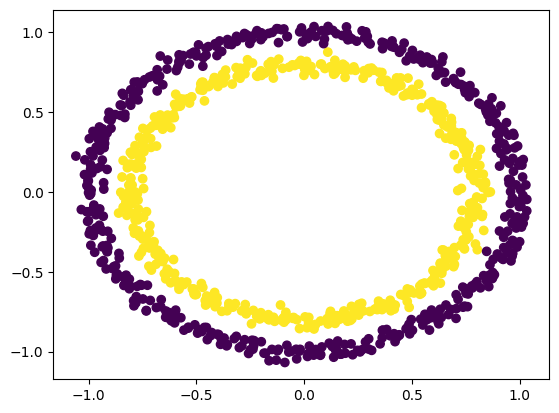

In [ ]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:,0],
            y=X[:,1],
            c=y)

In [ ]:
import torch

In [ ]:
# Turning data to tensor
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [ ]:
X[:5]

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])

In [ ]:
#Split data to training and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [ ]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

In [ ]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class CircleModelV0(nn.Module):
  def __init__(self, ) :
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self,x):
    return self.layer_2(self.layer_1(x)) # x to layer1 then to layer2
# instance creating
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
# Lets replicate model using sequntial
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [ ]:
untrained_preds = model_0(X_test.to(device))


In [ ]:
#seting up loss and optim
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params=model_0.parameters(),
    lr=0.1
)

In [ ]:
# Calculating accuracy
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

In [ ]:
#Building a training loop

In [ ]:
torch.manual_seed(42)

epochs = 100

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_0.train()
  #forward

  y_logits = model_0(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate loss / accuracy

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)
  # optimizer , backward, step
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  # inferencing
  with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Test loss
    test_loss = loss_fn(test_logits, test_pred)
    test_acc = accuracy_fn(y_test, test_pred)
    # Printing
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69796 | Acc: 51.88% | Test loss: 0.63057 | Test acc: 58.00%
Epoch: 10 | Loss: 0.69590 | Acc: 51.25% | Test loss: 0.64599 | Test acc: 53.00%
Epoch: 20 | Loss: 0.69490 | Acc: 51.62% | Test loss: 0.65559 | Test acc: 49.50%
Epoch: 30 | Loss: 0.69435 | Acc: 51.12% | Test loss: 0.66228 | Test acc: 49.50%
Epoch: 40 | Loss: 0.69401 | Acc: 50.88% | Test loss: 0.66769 | Test acc: 51.00%
Epoch: 50 | Loss: 0.69378 | Acc: 50.25% | Test loss: 0.67216 | Test acc: 50.00%
Epoch: 60 | Loss: 0.69362 | Acc: 50.00% | Test loss: 0.67592 | Test acc: 51.50%
Epoch: 70 | Loss: 0.69351 | Acc: 50.25% | Test loss: 0.67910 | Test acc: 51.00%
Epoch: 80 | Loss: 0.69342 | Acc: 49.88% | Test loss: 0.68181 | Test acc: 50.00%
Epoch: 90 | Loss: 0.69336 | Acc: 49.88% | Test loss: 0.68411 | Test acc: 53.00%


In [ ]:
# Visualizing the predictions

import requests
from pathlib import Path
# downloading healper functions
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists")
else:
  print("download healper functions fron git hub")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

helper_functions.py already exists


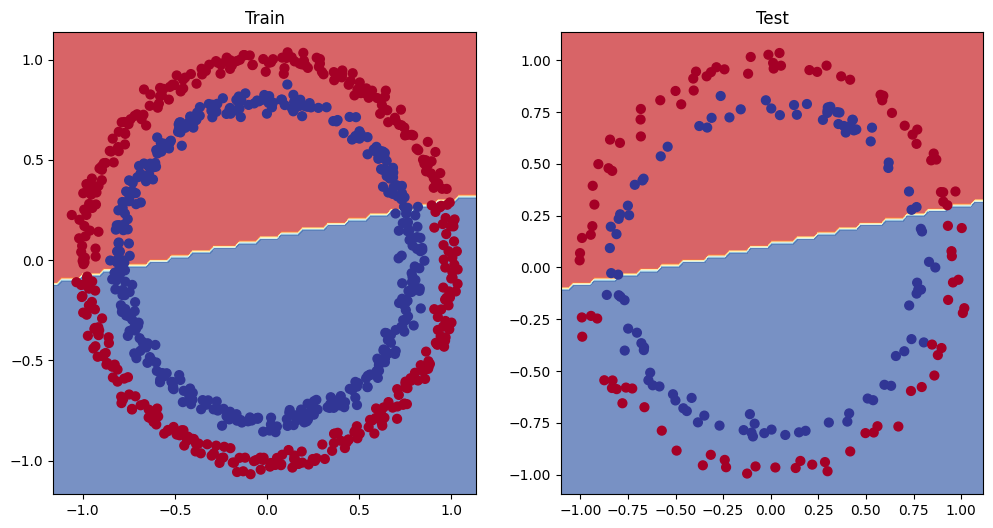

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

In [ ]:
class CircleModelV1(nn.Module):
  def __init__(self) :
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x):
    z = self.layer_1(x)
    z = self.layer_2(z)
    z = self.layer_3(z)
    return z

In [ ]:
model_1 = CircleModelV1().to(device)
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    params= model_1.parameters(),
    lr = 0.001
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_1.train()
  #forward

  y_logits = model_1(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate loss / accuracy

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)
  # optimizer , backward, step
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  # inferencing
  with torch.inference_mode():
    test_logits = model_1(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Test loss
    test_loss = loss_fn(test_logits, test_pred)
    test_acc = accuracy_fn(y_test, test_pred)
    # Printing
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69396 | Acc: 50.88% | Test loss: 0.66732 | Test acc: 50.00%
Epoch: 100 | Loss: 0.69298 | Acc: 51.12% | Test loss: 0.67633 | Test acc: 45.50%
Epoch: 200 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 300 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 400 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 500 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 600 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 700 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 800 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%
Epoch: 900 | Loss: 0.69298 | Acc: 51.00% | Test loss: 0.67617 | Test acc: 46.00%


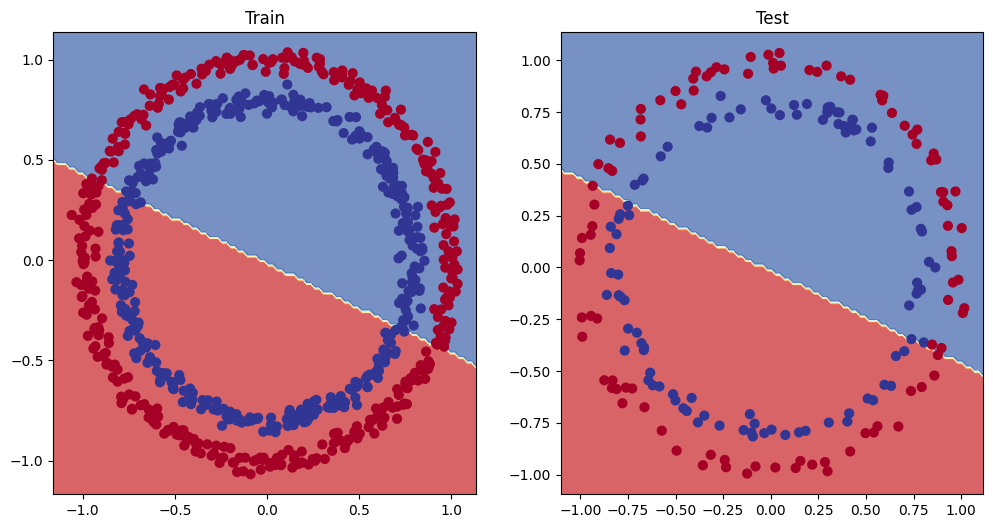

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)

#Building a Model with Non-Linearity

In [ ]:
from torch import nn
class CircleModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
model_2 = CircleModelV2()
model_2

CircleModelV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [ ]:
#seting up loss and optim
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    params=model_2.parameters(),
    lr=0.1
)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000

X_train, y_train, X_test, y_test = X_train.to(device), y_train.to(device), X_test.to(device), y_test.to(device)

for epoch in range(epochs):
  model_2.to(device)
  model_2.train()
  #forward

  y_logits = model_2(X_train).squeeze()
  y_pred = torch.round(torch.sigmoid(y_logits))

  # calculate loss / accuracy

  loss = loss_fn(y_logits, y_train)
  acc = accuracy_fn(y_train, y_pred)
  # optimizer , backward, step
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()
  # inferencing
  model_2.eval()
  with torch.inference_mode():

    test_logits = model_2(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Test loss
    test_loss = loss_fn(test_logits, y_test)
    test_acc = accuracy_fn(y_test, test_pred)
    # Printing
    if epoch % 100 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69295 | Acc: 50.00% | Test loss: 0.69319 | Test acc: 50.00%
Epoch: 100 | Loss: 0.69115 | Acc: 52.88% | Test loss: 0.69102 | Test acc: 52.50%
Epoch: 200 | Loss: 0.68977 | Acc: 53.37% | Test loss: 0.68940 | Test acc: 55.00%
Epoch: 300 | Loss: 0.68795 | Acc: 53.00% | Test loss: 0.68723 | Test acc: 56.00%
Epoch: 400 | Loss: 0.68517 | Acc: 52.75% | Test loss: 0.68411 | Test acc: 56.50%
Epoch: 500 | Loss: 0.68102 | Acc: 52.75% | Test loss: 0.67941 | Test acc: 56.50%
Epoch: 600 | Loss: 0.67515 | Acc: 54.50% | Test loss: 0.67285 | Test acc: 56.00%
Epoch: 700 | Loss: 0.66659 | Acc: 58.38% | Test loss: 0.66322 | Test acc: 59.00%
Epoch: 800 | Loss: 0.65160 | Acc: 64.00% | Test loss: 0.64757 | Test acc: 67.50%
Epoch: 900 | Loss: 0.62362 | Acc: 74.00% | Test loss: 0.62145 | Test acc: 79.00%


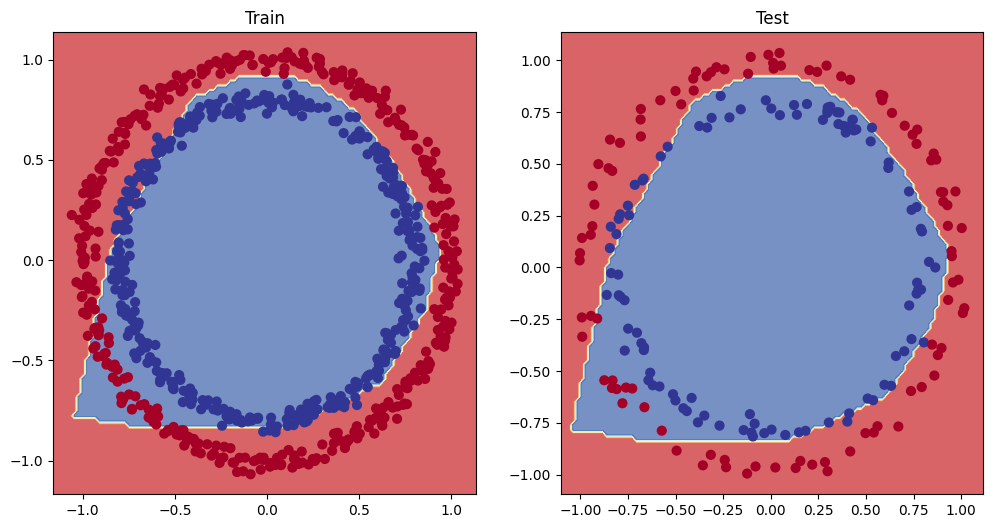

In [ ]:

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_2,X_train, y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_2, X_test, y_test)

# Multiclass Classsification


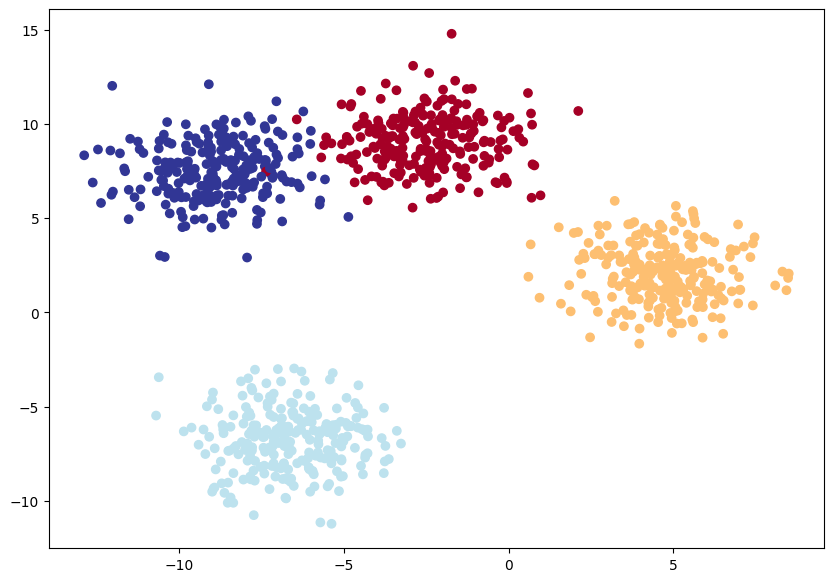

In [ ]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(n_samples=1000,
                            n_features=NUM_FEATURES,
                            centers=NUM_CLASSES,
                            cluster_std=1.5,
                            random_state=RANDOM_SEED)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(X_blob,
                                                                        y_blob,
                                                                        test_size=0.2,
                                                                        random_state=RANDOM_SEED)
plt.figure(figsize =(10,7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob,cmap=plt.cm.RdYlBu)

# Building the multiclass model

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class BlobModel(nn.Module):
  def __init__(self,in_features, out_features, hidden_unit=8):
    super().__init__()
    self.linear_layer_stack = nn.Sequential(
        nn.Linear(in_features=in_features, out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit, out_features=hidden_unit),
        nn.ReLU(),
        nn.Linear(in_features=hidden_unit, out_features=out_features)
    )

  def forward(self,x):
    return self.linear_layer_stack(x)

model_3 = BlobModel(in_features=2,
                    out_features=4).to(device)

In [ ]:
# Create a loss function
loss_fn = nn.CrossEntropyLoss()
# Optimizer setup for multiclass
optimizer = torch.optim.SGD(params = model_3.parameters(),
                      lr = 0.1)


In [ ]:
# training Multiclass Model
torch.manual_seed(42)
torch.cuda.manual_seed(42)
epochs = 100

X_blob_train, X_blob_test, y_blob_train, y_blob_test = X_blob_train.to(device),X_blob_test.to(device), y_blob_train.to(device),y_blob_test.to(device)
model_3.to(device)

for epoch in range(epochs):

  model_3.train()

  y_logits = model_3(X_blob_train)
  y_pred = torch.softmax(y_logits,dim = 1).argmax(dim=1)

  loss = loss_fn(y_logits, y_blob_train)
  train_acc = accuracy_fn(y_blob_train,y_pred)
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Evlauation Mode
  model_3.eval()
  torch.inference_mode()

  test_logits = model_3(X_blob_test)
  test_preds = torch.softmax(test_logits,dim= 1).argmax(dim=1)

  test_loss = loss_fn(test_logits,y_blob_test)
  test_acc = accuracy_fn(y_blob_test,test_preds)
  # Printing out

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.4f} | Test Loss: {test_loss:.4f} | Acc: {test_acc:.4f} | Train Acc: {train_acc}")


Epoch: 0 | Loss: 1.1588 | Test Loss: 1.0755 | Acc: 48.0000 | Train Acc: 40.375
Epoch: 10 | Loss: 0.6448 | Test Loss: 0.6607 | Acc: 97.5000 | Train Acc: 96.75
Epoch: 20 | Loss: 0.4254 | Test Loss: 0.4307 | Acc: 100.0000 | Train Acc: 98.5
Epoch: 30 | Loss: 0.2529 | Test Loss: 0.2451 | Acc: 99.5000 | Train Acc: 99.125
Epoch: 40 | Loss: 0.1123 | Test Loss: 0.1023 | Acc: 99.5000 | Train Acc: 99.25
Epoch: 50 | Loss: 0.0663 | Test Loss: 0.0585 | Acc: 99.5000 | Train Acc: 99.25
Epoch: 60 | Loss: 0.0507 | Test Loss: 0.0429 | Acc: 99.5000 | Train Acc: 99.25
Epoch: 70 | Loss: 0.0430 | Test Loss: 0.0349 | Acc: 99.5000 | Train Acc: 99.25
Epoch: 80 | Loss: 0.0384 | Test Loss: 0.0299 | Acc: 99.5000 | Train Acc: 99.25
Epoch: 90 | Loss: 0.0352 | Test Loss: 0.0266 | Acc: 99.5000 | Train Acc: 99.25


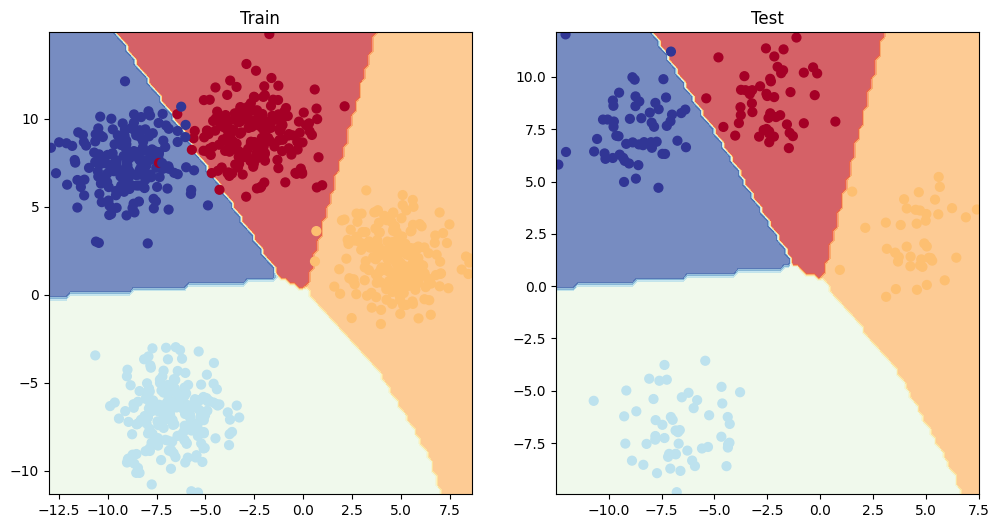

In [ ]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_3,X_blob_train, y_blob_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_3, X_blob_test, y_blob_test)